### Load data

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
#from sklearn.decomposition import PCA
import scipy.signal as signal
import statsmodels.api as sm
import pandas as pd
from seaborn import regplot
import pandas as pd
import glob

In [2]:
def weight_by_latitude(da):
    """Weight data array by cosine of latitude."""
    weights = np.cos(np.deg2rad(da['latitude']))
    weighted_da = da * weights
    return weighted_da


def reshape_to_2d(da):
    """Reshape (lat, lon, sample) data into 2D matrix (space x sample)."""
    space_dim = da['latitude'].size * da['longitude'].size
    ##modify here likely!
    reshaped = da.stack(space=('latitude', 'longitude')).transpose('sample', 'space')
    return reshaped


def compute_covariance_matrix(reshaped_da):
    """Compute the covariance matrix of the data."""
    data = reshaped_da.values
    data = data - np.nanmean(data, axis=0)  # Centering the data
    covariance_matrix = np.cov(data.T)
    return covariance_matrix


def perform_svd(cov_matrix):
    """Perform SVD on the covariance matrix."""
    U, S, Vt = np.linalg.svd(cov_matrix)
    return U, S, Vt


def plot_first_principal_component(reshaped_da, Vt):
    """Plot the first principal component as a map."""
    first_pc = Vt[0, :] #first eigenvector with largest eigenvalue
    pc_map = reshaped_da.isel(sample=0).copy() #.isel selects the i you give, make a copy of given array at i
    pc_map.values = first_pc #change the values from before to the first_pc values
    pc_map_unstacked = pc_map.unstack('space')

    plt.figure(figsize=(8, 5))
    pc_map_unstacked.plot(cmap='RdBu')
    plt.title("First Principal Component (Spatial Pattern)")
    plt.show()

    return pc_map_unstacked


def compute_zonal_mean(pc_map_unstacked):
    """Compute the zonal mean of the first principal component map."""
    zonal_mean = pc_map_unstacked.mean(dim='longitude')
    return zonal_mean

def make_zonal_mean_map(zonal_mean, da):
    """Create a zonal mean map, assigning each longitude the same value."""
    zonal_map = xr.zeros_like(da.isel(sample=0)) #blank map with same dimensions as da
    for lon in zonal_map['longitude']:
        zonal_map.loc[{'longitude': lon}] = zonal_mean #assign zonal mean value to each longitude
    return zonal_map

def regress_onto_zonal_mean_map(da, zonal_map):
    """Regress original data onto the zonal mean map (time series of coefficients)."""
#flattening data
    zonal_map_flat = zonal_map.stack(space=('latitude', 'longitude')).values
    data_flat = da.stack(space=('latitude', 'longitude')).transpose('sample', 'space').values
#detrending by removing mean
    zonal_map_flat = zonal_map_flat - np.nanmean(zonal_map_flat)
    data_flat = data_flat - np.nanmean(data_flat, axis=0)

    regression_coefficients = np.dot(data_flat, zonal_map_flat) / np.dot(zonal_map_flat, zonal_map_flat)

    return regression_coefficients


def plot_regression_coefficients(sample, regression_coefficients):
    """Plot regression coefficients over time."""
    plt.figure(figsize=(8, 5))
    plt.plot(sample, regression_coefficients, label='Regression Coefficients')
    plt.xlabel('Time')
    plt.ylabel('Coefficient')
    plt.title('Regression Coefficients Over Time')
    plt.grid()
    plt.show()
    

def seasonal_average(da):
    da2=da.groupby('time.year').mean('time')
    return(da2)

def stdize_ssavg(da):
    da2=(da-da.mean())/da.std()
    return da2

def drop_fake_members(da):
    valid_sample = (
        da.isel(season_month=0, latitude=slice(0, 5), longitude=slice(0, 5))
        .mean(("latitude", "longitude"), skipna=True)
        .notnull()
    )
    return da.where(valid_sample, drop=True)

## Handling seasonal forecasts

In [4]:
hc=xr.open_dataset('/climca/data/SEAS5_SA/data/seas5_pressure_levels_06-11month_1-5leadtimemonth.nc') #variable name is t2m

In [5]:
# Path to your NetCDF file
DATADIR='/climca/data/SEAS5_SA/data'
file = f"{DATADIR}/seas5_single_levels_06-11month_1-5leadtimemonth.nc"

# Open the dataset
# chunks is useful because your dataset is huge.
# It avoids loading everything into memory immediately.
ds = xr.open_dataset(
    file,
    chunks={
        "number": 1,
        "forecast_reference_time": 10,
        "forecastMonth": 6
    }
)

u_data=xr.open_dataset(DATADIR+'/seasonal_monthly_pressure_levels_wind_06-11month_1-5leadtime_month.nc', chunks={'number':1, 'forecast_reference_time':10, 'forecastMonth':6})
z500_data=xr.open_dataset(DATADIR+'/seas5_pressure_levels_06-11month_1-5leadtimemonth.nc', chunks={'number':1, 'forecast_reference_time':10, 'forecastMonth':6})

print(u_data)
print(z500_data)

/tmp/ipykernel_2313206/2788555543.py:8: UserWarning: The specified chunks separate the stored chunks along dimension "number" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(
/tmp/ipykernel_2313206/2788555543.py:8: UserWarning: The specified chunks separate the stored chunks along dimension "forecast_reference_time" starting at index 10. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(


<xarray.Dataset> Size: 33GB
Dimensions:                  (number: 51, forecast_reference_time: 251,
                              forecastMonth: 5, pressure_level: 2,
                              latitude: 181, longitude: 360)
Coordinates:
  * number                   (number) int64 408B 0 1 2 3 4 5 ... 46 47 48 49 50
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 2kB 198...
  * forecastMonth            (forecastMonth) int64 40B 1 2 3 4 5
  * pressure_level           (pressure_level) float64 16B 850.0 50.0
  * latitude                 (latitude) float64 1kB 90.0 89.0 ... -89.0 -90.0
  * longitude                (longitude) float64 3kB 0.0 1.0 2.0 ... 358.0 359.0
Data variables:
    u                        (number, forecast_reference_time, forecastMonth, pressure_level, latitude, longitude) float32 33GB dask.array<chunksize=(1, 10, 5, 1, 46, 90), meta=np.ndarray>
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescript

/tmp/ipykernel_2313206/2788555543.py:17: UserWarning: The specified chunks separate the stored chunks along dimension "number" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  u_data=xr.open_dataset(DATADIR+'/seasonal_monthly_pressure_levels_wind_06-11month_1-5leadtime_month.nc', chunks={'number':1, 'forecast_reference_time':10, 'forecastMonth':6})
/tmp/ipykernel_2313206/2788555543.py:17: UserWarning: The specified chunks separate the stored chunks along dimension "forecast_reference_time" starting at index 10. This could degrade performance. Instead, consider rechunking after loading.
  u_data=xr.open_dataset(DATADIR+'/seasonal_monthly_pressure_levels_wind_06-11month_1-5leadtime_month.nc', chunks={'number':1, 'forecast_reference_time':10, 'forecastMonth':6})
/tmp/ipykernel_2313206/2788555543.py:18: UserWarning: The specified chunks separate the stored chunks along dimension "number" starting at index 1. This could degrade performance. 

In [6]:
# ------------------------------------------------------------
# Make sure we have valid_time
# ------------------------------------------------------------
# valid_time = real calendar month of the forecast
#
# Example:
# forecast_reference_time = 1981-09-01
# forecastMonth = 1 -> valid_time = 1981-09-01
# forecastMonth = 2 -> valid_time = 1981-10-01
# forecastMonth = 3 -> valid_time = 1981-11-01
# forecastMonth = 4 -> valid_time = 1981-12-01
# forecastMonth = 5 -> valid_time = 1982-01-01
# forecastMonth = 6 -> valid_time = 1982-02-01

#For instance for a forecast with start date on the 1st May, forecastMonth=1 is May,
#  and for a forecast with start date on 17th April, forecastMonth=1 would also be May. 
# This is more coherent and avoids the ambiguity described above.
def make_valid_time(ds):
    if "valid_time" in ds.data_vars:
        # Sometimes valid_time exists but is stored as a data variable.
        # We promote it to a coordinate.
        ds = ds.set_coords("valid_time")


    elif "valid_time" not in ds.coords:
        # If valid_time does not exist, we create it manually.

        init_times = pd.to_datetime(ds["forecast_reference_time"].values)
        lead_months = ds["forecastMonth"].values

        valid_times = []

        for init in init_times:
            valid_times_this_init = []

            for lead in lead_months:
                this_valid_time = init + pd.DateOffset(months=int(lead) - 1)
                valid_times_this_init.append(this_valid_time)

            valid_times.append(valid_times_this_init)

        valid_times = np.array(valid_times, dtype="datetime64[ns]")

        ds = ds.assign_coords(
            valid_time=(
                ("forecast_reference_time", "forecastMonth"),
                valid_times
            )
        )

    print(ds["valid_time"])
    return ds

ds=make_valid_time(ds)
u_data=make_valid_time(u_data)
z500_data=make_valid_time(z500_data)

<xarray.DataArray 'valid_time' (forecast_reference_time: 251, forecastMonth: 5)> Size: 10kB
array([['1981-06-01T00:00:00.000000000', '1981-07-01T00:00:00.000000000',
        '1981-08-01T00:00:00.000000000', '1981-09-01T00:00:00.000000000',
        '1981-10-01T00:00:00.000000000'],
       ['1981-07-01T00:00:00.000000000', '1981-08-01T00:00:00.000000000',
        '1981-09-01T00:00:00.000000000', '1981-10-01T00:00:00.000000000',
        '1981-11-01T00:00:00.000000000'],
       ['1981-08-01T00:00:00.000000000', '1981-09-01T00:00:00.000000000',
        '1981-10-01T00:00:00.000000000', '1981-11-01T00:00:00.000000000',
        '1981-12-01T00:00:00.000000000'],
       ...,
       ['2022-08-01T00:00:00.000000000', '2022-09-01T00:00:00.000000000',
        '2022-10-01T00:00:00.000000000', '2022-11-01T00:00:00.000000000',
        '2022-12-01T00:00:00.000000000'],
       ['2022-09-01T00:00:00.000000000', '2022-10-01T00:00:00.000000000',
        '2022-11-01T00:00:00.000000000', '2022-12-01T00:00:00.

In [7]:
u_data.valid_time.sel(
    forecast_reference_time="1981-09-01"
).values

array(['1981-09-01T00:00:00.000000000', '1981-10-01T00:00:00.000000000',
       '1981-11-01T00:00:00.000000000', '1981-12-01T00:00:00.000000000',
       '1982-01-01T00:00:00.000000000'], dtype='datetime64[ns]')

In [9]:
def make_3_month_block(ds, lead_months, block_name):
    """
    Select a 3-month forecast block.

    lead_months can be:
        [1, 2, 3]
        [4, 5, 6]

    block_name is just a label:
        "lead_1_2_3"
        "lead_4_5_6"
    """

    block = ds.sel(forecastMonth=lead_months)

    block = block.assign_coords(
        original_forecastMonth=("forecastMonth", lead_months)
    )

    block = block.rename({"forecastMonth": "season_month"})

    block = block.assign_coords(
        season_month=[1, 2, 3]
    )

    block = block.assign_coords(
        lead_block=block_name
    )

    return block

In [10]:
# block_1 = make_3_month_block(ds, [1, 2, 3], "lead_1_2_3") #creates two independent 3-month windows
block_2 = make_3_month_block(ds, [2, 3, 4], "lead_2_3_4") #for init in Aug 2,3,4 would be SON 
block_3 = make_3_month_block(ds, [3, 4, 5], "lead_3_4_5") #for init in July 3,4,5 would be SON 
#for init in Oct 1,2,3 would be OND and 4,5,6 JFM

# block_1_u=make_3_month_block(u_data, [1,2,3], 'lead_1_2_3')
block_2_u = make_3_month_block(u_data, [2, 3, 4], "lead_2_3_4") 
block_3_u = make_3_month_block(u_data, [3, 4, 5], "lead_3_4_5") 

# block_1_z=make_3_month_block(z500_data, [1,2,3], 'lead_1_2_3')
block_2_z= make_3_month_block(z500_data, [2, 3, 4], "lead_2_3_4")
block_3_z=make_3_month_block(z500_data, [3, 4, 5], "lead_3_4_5")

In [12]:
ds_3m = xr.concat(
    [block_2, block_3],
    dim=xr.DataArray(
        ["lead_2_3_4","lead_3_4_5"],
        dims="lead_block",
        name="lead_block"
    )
)

u_data_3m = xr.concat(
    [block_2_u,block_3_u],
    dim=xr.DataArray(
        ["lead_2_3_4","lead_3_4_5"],
        dims="lead_block",
        name="lead_block"
    )
)

z500_data_3m = xr.concat(
    [block_2_z,block_3_z],
    dim=xr.DataArray(
        ["lead_2_3_4","lead_3_4_5"],
        dims="lead_block",
        name="lead_block"
    )
)

print(ds_3m)

/tmp/ipykernel_2313206/3178029114.py:1: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_3m = xr.concat(
/tmp/ipykernel_2313206/3178029114.py:10: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  u_data_3m = xr.concat(


<xarray.Dataset> Size: 80GB
Dimensions:                  (lead_block: 2, number: 51,
                              forecast_reference_time: 251, season_month: 3,
                              latitude: 181, longitude: 360)
Coordinates:
  * number                   (number) int64 408B 0 1 2 3 4 5 ... 46 47 48 49 50
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 2kB 198...
  * latitude                 (latitude) float64 1kB 90.0 89.0 ... -89.0 -90.0
  * longitude                (longitude) float64 3kB 0.0 1.0 2.0 ... 358.0 359.0
    valid_time               (lead_block, forecast_reference_time, season_month) datetime64[ns] 12kB ...
    original_forecastMonth   (lead_block, season_month) int64 48B 2 3 4 3 4 5
  * season_month             (season_month) int64 24B 1 2 3
  * lead_block               (lead_block) <U10 80B 'lead_2_3_4' 'lead_3_4_5'
Data variables:
    t2m                      (lead_block, number, forecast_reference_time, season_month, latitude, longitude

/tmp/ipykernel_2313206/3178029114.py:19: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  z500_data_3m = xr.concat(


In [13]:
#one sample consists of one ensemble member, one initialization date, one lead block 
#e.g. sample #1234: member 17, initialized 1981-09-01, lead_4_5_6 
# -->season_month=1 -> Dec 1981
# season_month=2 -> Jan 1982
# season_month=3 -> Feb 1982

ds_3m = ds_3m.stack(
    sample=("lead_block", "forecast_reference_time", "number")
)


ds_3m = ds_3m.transpose(
    "sample",
    "season_month",
    "latitude",
    "longitude"
)

print(ds_3m)

u_data_3m = u_data_3m.stack(
    sample=("lead_block", "forecast_reference_time", "number")
)

u50_3m=u_data_3m.sel(pressure_level=50)
u850_3m=u_data_3m.sel(pressure_level=850)
u50_data_3m = u50_3m.transpose(
    "sample",
    "season_month",
    "latitude",
    "longitude"
)
u850_data_3m = u850_3m.transpose(
    "sample",
    "season_month",
    "latitude",
    "longitude"
)

z500_data_3m = z500_data_3m.isel(pressure_level=0).stack(
    sample=("lead_block", "forecast_reference_time", "number")
)


z500_data_3m = z500_data_3m.transpose(
    "sample",
    "season_month",
    "latitude",
    "longitude"
)

print(z500_data_3m)

<xarray.Dataset> Size: 80GB
Dimensions:                  (season_month: 3, latitude: 181, longitude: 360,
                              sample: 25602)
Coordinates:
  * latitude                 (latitude) float64 1kB 90.0 89.0 ... -89.0 -90.0
  * longitude                (longitude) float64 3kB 0.0 1.0 2.0 ... 358.0 359.0
    valid_time               (sample, season_month) datetime64[ns] 614kB 1981...
    original_forecastMonth   (sample, season_month) int64 614kB 2 3 4 ... 3 4 5
  * season_month             (season_month) int64 24B 1 2 3
  * sample                   (sample) object 205kB MultiIndex
  * lead_block               (sample) <U10 1MB 'lead_2_3_4' ... 'lead_3_4_5'
  * forecast_reference_time  (sample) datetime64[ns] 205kB 1981-06-01 ... 202...
  * number                   (sample) int64 205kB 0 1 2 3 4 5 ... 46 47 48 49 50
Data variables:
    t2m                      (sample, season_month, latitude, longitude) float32 20GB dask.array<chunksize=(8, 3, 37, 90), meta=np.ndarray>

In [14]:
def months_to_season_name(months):
    """
    Convert three month numbers into a season name.
    """

    months = tuple(months)

    season_dict = {
        (9, 10, 11): "SON",
        (10, 11, 12): "OND",
        (11, 12, 1): "NDJ",
        (12, 1, 2): "DJF",
        (1, 2, 3): "JFM",
        (2, 3, 4): "FMA",
        (3, 4, 5): "MAM",
        (4, 5, 6): "AMJ",
        (5, 6, 7): "MJJ",
    }

    return season_dict.get(months, "OTHER")

In [15]:
real_seasons = []
real_months = []
season_labels = []

for i in range(ds_3m.sizes["sample"]):

    # These are the 3 real calendar dates of this sample
    dates = pd.to_datetime(ds_3m["valid_time"].isel(sample=i).values)

    # Example: [9, 10, 11]
    months = [int(d.month) for d in dates]

    # Example: [1981, 1981, 1981]
    years = [int(d.year) for d in dates]

    season_name = months_to_season_name(months)

    real_seasons.append(season_name)
    real_months.append("-".join([f"{m:02d}" for m in months]))

    if years[0] == years[-1]:
        label = f"{season_name}_{years[0]}"
    else:
        label = f"{season_name}_{years[0]}_{years[-1]}"

    season_labels.append(label)

ds_3m = ds_3m.assign_coords(
    real_season=("sample", real_seasons),
    real_months=("sample", real_months),
    season_label=("sample", season_labels)
)

u50_data_3m = u50_data_3m.assign_coords(
    real_season=("sample", real_seasons),
    real_months=("sample", real_months),
    season_label=("sample", season_labels)
)

u850_data_3m = u850_data_3m.assign_coords(
    real_season=("sample", real_seasons),
    real_months=("sample", real_months),
    season_label=("sample", season_labels)
)

z500_data_3m=z500_data_3m.assign_coords(
    real_season=("sample", real_seasons),
    real_months=("sample", real_months),
    season_label=("sample", season_labels))

In [16]:
for i in np.arange(180,200,2):
    print(
        ds_3m.forecast_reference_time.isel(sample=i).values,
        ds_3m.lead_block.isel(sample=i).values,
        ds_3m.valid_time.isel(sample=i).values,
        ds_3m.real_season.isel(sample=i).values
    )

1981-09-01T00:00:00.000000000 lead_2_3_4 ['1981-10-01T00:00:00.000000000' '1981-11-01T00:00:00.000000000'
 '1981-12-01T00:00:00.000000000'] OND
1981-09-01T00:00:00.000000000 lead_2_3_4 ['1981-10-01T00:00:00.000000000' '1981-11-01T00:00:00.000000000'
 '1981-12-01T00:00:00.000000000'] OND
1981-09-01T00:00:00.000000000 lead_2_3_4 ['1981-10-01T00:00:00.000000000' '1981-11-01T00:00:00.000000000'
 '1981-12-01T00:00:00.000000000'] OND
1981-09-01T00:00:00.000000000 lead_2_3_4 ['1981-10-01T00:00:00.000000000' '1981-11-01T00:00:00.000000000'
 '1981-12-01T00:00:00.000000000'] OND
1981-09-01T00:00:00.000000000 lead_2_3_4 ['1981-10-01T00:00:00.000000000' '1981-11-01T00:00:00.000000000'
 '1981-12-01T00:00:00.000000000'] OND
1981-09-01T00:00:00.000000000 lead_2_3_4 ['1981-10-01T00:00:00.000000000' '1981-11-01T00:00:00.000000000'
 '1981-12-01T00:00:00.000000000'] OND
1981-09-01T00:00:00.000000000 lead_2_3_4 ['1981-10-01T00:00:00.000000000' '1981-11-01T00:00:00.000000000'
 '1981-12-01T00:00:00.00000000

In [17]:
print(ds_3m["real_season"].to_series().value_counts())

real_season
OTHER    6426
SON      4284
OND      4284
NDJ      4284
DJF      4233
JFM      2091
Name: count, dtype: int64


In [24]:
SON = ds_3m.where(ds_3m["real_season"] == "SON", drop=True)

DJF = ds_3m.where(ds_3m["real_season"] == "DJF", drop=True)

SON_DJF = ds_3m.where(
    ds_3m["real_season"].isin(["SON", "DJF"]),
    drop=True
)

# SON = drop_fake_members(ds_3m.where(ds_3m["real_season"] == "SON", drop=True))
# DJF = drop_fake_members(ds_3m.where(ds_3m["real_season"] == "DJF", drop=True))

# SON_DJF = drop_fake_members(
#     ds_3m.where(ds_3m["real_season"].isin(["SON", "DJF"]), drop=True)
# )

print("SON samples:", SON.sizes["sample"])
print("DJF samples:", DJF.sizes["sample"])
print("SON + DJF samples:", SON_DJF.sizes["sample"])

SON samples: 4284
DJF samples: 4233
SON + DJF samples: 8517


In [ ]:
SON_u50 = u50_data_3m.where(u50_data_3m["real_season"] == "SON", drop=True)
DJF_u50 = u50_data_3m.where(u50_data_3m["real_season"] == "DJF", drop=True)
SON_DJF_u50 = u50_data_3m.where(
    u50_data_3m["real_season"].isin(["SON", "DJF"]),
    drop=True
)

SON_u850 = u850_data_3m.where(u850_data_3m["real_season"] == "SON", drop=True)
DJF_u850 = u850_data_3m.where(u850_data_3m["real_season"] == "DJF", drop=True)
SON_DJF_u850 = u850_data_3m.where(
    u850_data_3m["real_season"].isin(["SON", "DJF"]),
    drop=True
)

SON_z500 = z500_data_3m.where(z500_data_3m["real_season"] == "SON", drop=True)
DJF_z500 = z500_data_3m.where(z500_data_3m["real_season"] == "DJF", drop=True)
SON_DJF_z500 = z500_data_3m.where(
    z500_data_3m["real_season"].isin(["SON", "DJF"]),
    drop=True
)


In [25]:
for i in range(5):
    print("sample:", i)
    print("season:", SON_DJF["real_season"].isel(sample=i).values)
    print("label:", SON_DJF["season_label"].isel(sample=i).values)
    print("lead block:", SON_DJF["lead_block"].isel(sample=i).values)
    print("init:", SON_DJF["forecast_reference_time"].isel(sample=i).values)
    print("valid months:", SON_DJF["valid_time"].isel(sample=i).values)
    print()

sample: 0
season: SON
label: SON_1981
lead block: lead_2_3_4
init: 1981-08-01T00:00:00.000000000
valid months: ['1981-09-01T00:00:00.000000000' '1981-10-01T00:00:00.000000000'
 '1981-11-01T00:00:00.000000000']

sample: 1
season: SON
label: SON_1981
lead block: lead_2_3_4
init: 1981-08-01T00:00:00.000000000
valid months: ['1981-09-01T00:00:00.000000000' '1981-10-01T00:00:00.000000000'
 '1981-11-01T00:00:00.000000000']

sample: 2
season: SON
label: SON_1981
lead block: lead_2_3_4
init: 1981-08-01T00:00:00.000000000
valid months: ['1981-09-01T00:00:00.000000000' '1981-10-01T00:00:00.000000000'
 '1981-11-01T00:00:00.000000000']

sample: 3
season: SON
label: SON_1981
lead block: lead_2_3_4
init: 1981-08-01T00:00:00.000000000
valid months: ['1981-09-01T00:00:00.000000000' '1981-10-01T00:00:00.000000000'
 '1981-11-01T00:00:00.000000000']

sample: 4
season: SON
label: SON_1981
lead block: lead_2_3_4
init: 1981-08-01T00:00:00.000000000
valid months: ['1981-09-01T00:00:00.000000000' '1981-10-01T

In [31]:
SON_DJF

<xarray.Dataset> Size: 27GB
Dimensions:                  (sample: 8517, season_month: 3, latitude: 181,
                              longitude: 360)
Coordinates:
  * latitude                 (latitude) float64 1kB 90.0 89.0 ... -89.0 -90.0
  * longitude                (longitude) float64 3kB 0.0 1.0 2.0 ... 358.0 359.0
    valid_time               (sample, season_month) datetime64[ns] 204kB 1981...
    original_forecastMonth   (sample, season_month) int64 204kB 2 3 4 ... 3 4 5
  * season_month             (season_month) int64 24B 1 2 3
  * sample                   (sample) object 68kB MultiIndex
  * lead_block               (sample) <U10 341kB 'lead_2_3_4' ... 'lead_3_4_5'
  * forecast_reference_time  (sample) datetime64[ns] 68kB 1981-08-01 ... 2022...
  * number                   (sample) int64 68kB 0 1 2 3 4 5 ... 46 47 48 49 50
    real_season              (sample) <U5 170kB 'SON' 'SON' ... 'DJF' 'DJF'
    real_months              (sample) <U8 273kB '09-10-11' ... '12-01-02'
    season_label             (sample) <U13 443kB 'SON_1981' ... 'DJF_2022_2023'
Data variables:
    t2m                      (sample, season_month, latitude, longitude) float32 7GB dask.array<chunksize=(8, 3, 37, 90), meta=np.ndarray>
    msl                      (sample, season_month, latitude, longitude) float32 7GB dask.array<chunksize=(8, 3, 37, 90), meta=np.ndarray>
    sst                      (sample, season_month, latitude, longitude) float32 7GB dask.array<chunksize=(8, 3, 37, 90), meta=np.ndarray>
    tprate                   (sample, season_month, latitude, longitude) float32 7GB dask.array<chunksize=(8, 3, 37, 90), meta=np.ndarray>
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-29T19:49 GRIB to CDM+CF via cfgrib-0.9.1...

In [35]:
SON_mean = SON.mean(dim="season_month")
DJF_mean = DJF.mean(dim="season_month")

# Data preparation

In [36]:
def select_region(ds, lat_min, lat_max, lon_min, lon_max):
    """
    Select a latitude-longitude box.

    Works even if latitude is ordered north-to-south, as in ERA5/SEAS5:
        90, 89, 88, ..., -90

    Longitude in your dataset is 0 to 360.
    So:
        -76 to -70 becomes 284 to 290
        -62 to -49 becomes 298 to 311
    """

    lat = ds["latitude"]

    # If latitude is decreasing: 90, 89, ..., -90
    if lat[0] > lat[-1]:
        lat_slice = slice(lat_max, lat_min)
    else:
        lat_slice = slice(lat_min, lat_max)

    out = ds.sel(
        latitude=lat_slice,
        longitude=slice(lon_min, lon_max)
    )

    return out

def compute_sample_anomaly(ds):
    """
    Compute anomaly across all samples.

    For each grid point:
        anomaly = value - mean over samples

    This keeps all ensemble members and all years.
    """

    return ds - ds.mean(dim="sample")

def detrend_across_time(ds):
    """
    Remove a linear trend across time.

    Important:
    Your dimension is called 'sample', not 'time'.

    Each sample has a coordinate called 'forecast_reference_time'.
    We extract the year from that coordinate and regress each grid point
    against year.

    Because you have 51 ensemble members per year, the same year appears
    many times. That is okay: the trend is fitted across all samples.
    """

    # Extract year from forecast_reference_time
    years = xr.DataArray(
        ds["forecast_reference_time"].dt.year.values,
        dims="sample",
        coords={"sample": ds["sample"]},
        name="year"
    )

    # Center the year to make the regression numerically cleaner
    x = years - years.mean(dim="sample")

    # Output container
    detrended_vars = {}

    for var in ds.data_vars:

        y = ds[var]

        # Mean over sample
        y_mean = y.mean(dim="sample")

        # Linear regression slope:
        # slope = cov(x, y) / var(x)
        slope = ((x * (y - y_mean)).mean(dim="sample")) / ((x ** 2).mean(dim="sample"))

        # Fitted linear trend
        fit = y_mean + slope * x

        # Remove fitted trend
        detrended_vars[var] = y - fit

    out = xr.Dataset(detrended_vars, coords=ds.coords)

    return out


def spatial_average(ds):
    """
    Latitude-weighted spatial average.

    Output:
        one value per sample
    """

    weights = np.cos(np.deg2rad(ds["latitude"]))

    out = ds.weighted(weights).mean(dim=["latitude", "longitude"])

    return out

def standardize(ds):
    """
    Standardize each variable across samples.

    z = value / std

    The mean should already be near zero after anomaly + detrending.
    If you want strict z-score, use:
        (ds - ds.mean("sample")) / ds.std("sample")
    """

    return ds / ds.std(dim="sample")

def process_region(ds_season, lat_min, lat_max, lon_min, lon_max):
    """
    Full pipeline for one region and one season.

    Input:
        ds_season = SON_mean or DJF_mean

    Output:
        standardized anomaly time series for all samples
    """

    # 1. Select region
    region = select_region(
        ds_season,
        lat_min=lat_min,
        lat_max=lat_max,
        lon_min=lon_min,
        lon_max=lon_max
    )

    # 2. Anomaly over samples
    region_an = compute_sample_anomaly(region)

    # 3. Remove linear trend across time/sample
    region_detr = detrend_across_time(region_an)

    # 4. Spatial average
    region_avg = spatial_average(region_detr)

    # 5. Standardize
    region_std = standardize(region_avg)

    return region_std




ENSO and IOD

In [46]:
def ENSO_process(sst):
    'Computation of Nino3.4 index from sst field (ideally already monthly)'

    print('Start ENSO comp')
    sst_nino = select_region(
        sst,
        lat_min=-5,
        lat_max=5,
        lon_min=190,
        lon_max=240
    ) #fixed region
    sst_anomaly_nino=compute_sample_anomaly(sst_nino)
    sst_anomaly_nino_weighted=spatial_average(sst_anomaly_nino)
    
    nino_detr=detrend_across_time(sst_anomaly_nino_weighted)
    print('Detrended ENSO')
    
    sst_anomaly_smoothed = nino_detr.rolling(sample=5, center=True).mean()
    nino34_index=standardize(sst_anomaly_smoothed)
    nino34_index=nino34_index.rename({'sst':'nino34'})
    print('ENSO index computed')
    return nino34_index

from scipy.signal import butter, filtfilt

# Function to apply a low-pass filter (removes >7-year variations)

def lowpass_filter(da, cutoff=1/7, fs=12):
    nyq=fs/2
    wn=cutoff/nyq #standardising my input frequency with nyquist
    # Design the Butterworth filter
    b, a = butter(N=6, Wn=wn, btype='high', fs=fs) 
    #actually it is high pass because low frequency signal acts on long timescales

    # Define a function to apply the filter on 1D time series
    def filter_1d(x):
        if np.any(np.isnan(x)):  # Handle NaNs
            x = np.nan_to_num(x, nan=np.nanmean(x))  # Replace NaNs with mean
        return filtfilt(b, a, x)

    # Apply the filter along the 'time' dimension
    filtered_da = xr.apply_ufunc(
        filter_1d, 
        da, 
        input_core_dims=[["sample"]],  # Apply only along 'sample'
        output_core_dims=[["sample"]],
        vectorize=True  # Ensures it works for each lat/lon point
    )

    return filtered_da

# Function to apply a 3-month running mean
def running_mean(da, window=3):
    return da.rolling(time=window, center=True).mean()

def IOD_process(sst):
    ##modify to adapt worklfow of julia
    '''Computation procedure for IOD index'''
    print('Start IOD comp')
    sst_io_eastweighted=select_region(sst, lat_min=-10, 
                                      lat_max=0,
                                      lon_min=90,
                                      lon_max=110)
    sst_io_westweighted=select_region(sst, lat_min=-10,
                                      lat_max=10,
                                      lon_max=70,
                                      lon_min=50)
   
    #weight by lat and spatial avg after anomaly comp
    sst_anom_ioe=spatial_average(compute_sample_anomaly(sst_io_eastweighted))
    sst_anom_iow=spatial_average(compute_sample_anomaly(sst_io_westweighted))
    print('Anomaly computed')
    #detrend
    ioe_detr=detrend_across_time(sst_anom_ioe).compute()
    iow_detr=detrend_across_time(sst_anom_iow).compute()

    #filter high freqs
    print('Start lowpass')
    ioe_filtered=lowpass_filter(ioe_detr)
    iow_filtered=lowpass_filter(iow_detr)
    #smooth and compute IOD index
    iode_smoothed=ioe_filtered.rolling(sample=3, center=True).mean()
    iodw_smoothed=iow_filtered.rolling(sample=3, center=True).mean()
    iod_index=iodw_smoothed-iode_smoothed
    iod_index_ssavg=standardize(iod_index).rename({'sst':'iod_index'})
    print('IOD index computed')
    return iod_index_ssavg

In [47]:
#use SON_mean and DJF_mean?
sst_SON=SON_mean[['sst']]
sst_DJF=DJF_mean[['sst']]
nino_SON=ENSO_process(sst_SON)
nino_DJF=ENSO_process(sst_DJF)


Start ENSO comp
Detrended ENSO
ENSO index computed
Start ENSO comp
Detrended ENSO
ENSO index computed


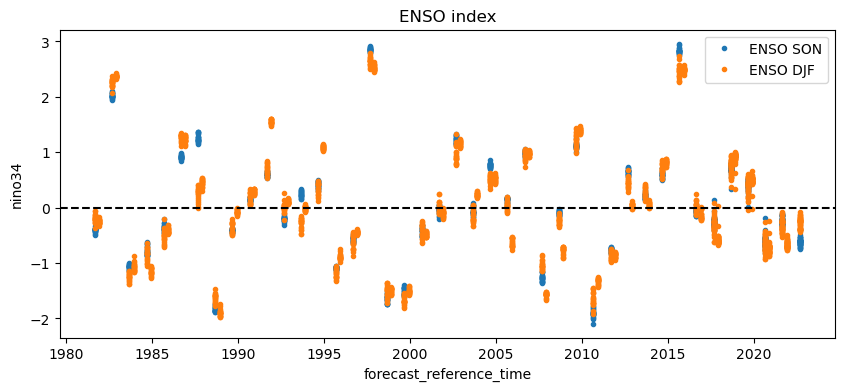

In [37]:
plt.figure(figsize=(10, 4))

nino_SON["nino34"].plot(
    x="forecast_reference_time",
    marker=".",
    linestyle="none",
    label="ENSO SON"
)

nino_DJF["nino34"].plot(
    x="forecast_reference_time",
    marker=".",
    linestyle="none",
    label="ENSO DJF"
)

plt.axhline(0, color="black", linestyle="dashed")
plt.legend()
plt.title("ENSO index")
plt.show()

Start IOD comp
Anomaly computed
Start lowpass
IOD index computed


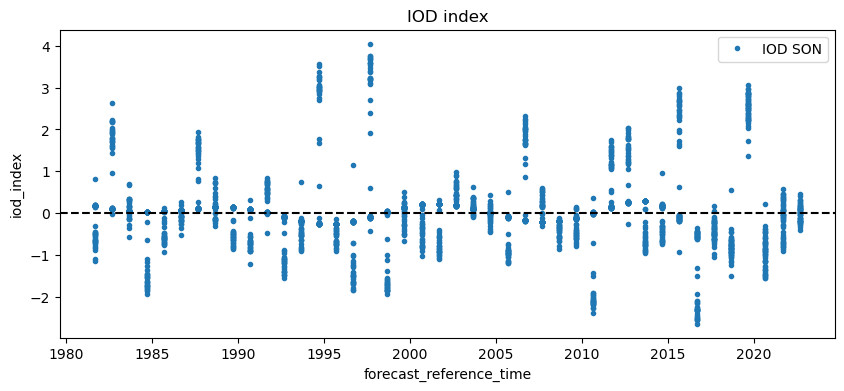

In [38]:
##IOD
IOD_SON=IOD_process(sst_SON)
plt.figure(figsize=(10, 4))

IOD_SON["iod_index"].plot(
    x="forecast_reference_time",
    marker=".",
    linestyle="none",
    label="IOD SON"
)

plt.axhline(0, color="black", linestyle="dashed")
plt.legend()
plt.title("IOD index")
plt.show()

In [50]:
## save ocean drivers in nc file

ds_ocean_SON=xr.merge([IOD_SON, nino_SON])
ds_ocean_SON=ds_ocean_SON.reset_index('sample')
encoding_ocean = {var: {"zlib": True, "complevel": 4} for var in ds_ocean_SON.data_vars}
ds_ocean_SON.to_netcdf(save_path+save_folder+'/ENSO_IOD_SON.nc', encoding=encoding_ocean)

IOBW

In [48]:
##IOBW
def IOBW_process(sst):
    sst_io_whole=select_region(sst,
                               lat_max=26,
                               lat_min=-26, 
                               lon_max=120,
                               lon_min=30).sortby('latitude', ascending=True)

    #1 seasonal data extraction -->done before already
    #sst_DJF=extract_seasonal_data(sst_io_whole, seasons=[12, 1, 2])
    #2 compute anomaly
    sst_DJF_anom=compute_sample_anomaly(sst_io_whole)
    print('Anomaly computed')
    #detrend
    sst_detr=detrend_across_time(sst_DJF_anom)

    #3 compute PCs (including weight by latitude)
    sst_DJF_anom_weighted=weight_by_latitude(sst_detr)
    X = sst_DJF_anom_weighted["sst"]

    valid_space = (~np.isnan(X).any(dim="sample")).compute()
    print('Mask generated')
    X_clean = X.where(valid_space, drop=True).compute() #more robust way to drop all NaN
    #display(sst_DJF_anom_weighted)
    reshaped_sst_DJF=reshape_to_2d(X_clean)

    #4 "SAM" procedure applied here
    #cov_matrix=compute_covariance_matrix(reshaped_sst_DJF) not necessary?
    #display(cov_matrix)
    print('Performing PCA...')
    U, S, Vt=perform_svd(reshaped_sst_DJF)
    print(U.shape, S.shape, Vt.shape)
    #pc_map_unstacked=plot_first_principal_component(reshaped_sst_DJF, Vt)

    PC1 = U[:, 0] * S[0] #index before normalisation
    PC1_ts = xr.DataArray(
        PC1,
        coords={"sample": reshaped_sst_DJF.sample},
        dims=["sample"],
        name="IOBW"
    )
    print('PCA finished')
    #multiply by -1 to match the sign of the IOBW index (positive = earlier breakdown)
    PC1_ts = -PC1_ts
    
    #seasonal averages and standardise again
    IOBW_ssavg_DJF=standardize(PC1_ts)
    #IOBW_index=IOBW_ssavg_DJF.rename({'sst':'iobw_index'})
    return IOBW_ssavg_DJF

In [ ]:
IOBW_index=IOBW_process(sst_DJF)

In [76]:
sst_io_whole=select_region(sst_DJF,
                               lat_max=26,
                               lat_min=-26, 
                               lon_max=120,
                               lon_min=30).sortby('latitude', ascending=True)

    #1 seasonal data extraction -->done before already
    #sst_DJF=extract_seasonal_data(sst_io_whole, seasons=[12, 1, 2])
    #2 compute anomaly
sst_DJF_anom=compute_sample_anomaly(sst_io_whole)
print('Anomaly computed')
    #detrend
sst_detr=detrend_across_time(sst_DJF_anom)

    #3 compute PCs (including weight by latitude)
sst_DJF_anom_weighted=weight_by_latitude(sst_detr)
#print(sst_DJF_anom_weighted)
print('SST weighted')
X = sst_DJF_anom_weighted["sst"]

valid_space = (~np.isnan(X).any(dim="sample")).compute()
print('Mask generated')
X_clean = X.where(valid_space, drop=True)
print(np.isnan(X_clean).sum())

Anomaly computed
<xarray.DataArray 'sst' ()> Size: 8B
dask.array<sum-aggregate, shape=(), dtype=int64, chunksize=(), chunktype=numpy.ndarray>


In [77]:
print(np.isnan(X_clean).sum().compute())

<xarray.DataArray 'sst' ()> Size: 8B
array(0)


In [ ]:
plt.figure(figsize=(10, 4))

IOBW_index["sst"].plot(
    x="forecast_reference_time",
    marker=".",
    linestyle="none",
    label="IOB DJF"
)

plt.axhline(0, color="black", linestyle="dashed")
plt.legend()
plt.title("IOB index")
plt.show()

SAM

In [75]:
def SAM_process_fast(zg):
    """Put in seasonal values of Z500 field."""

    # If input is a Dataset, select the variable z
    if isinstance(zg, xr.Dataset):
        zg = zg["z"]

    field_io_whole = select_region(
        zg,
        lat_max=-20,
        lat_min=-90,
        lon_max=360,
        lon_min=0
    )

    field_anom = compute_sample_anomaly(field_io_whole)
    field_anom_seasonal = field_anom.mean(dim="season_month")
    print("Anomaly computed")

    field_anom_weighted = weight_by_latitude(field_anom_seasonal)

    field_anom_weighted = field_anom_weighted.transpose(
        "sample", "latitude", "longitude"
    ).load()

    reshaped_field_anom = field_anom_weighted.stack(
        space=("latitude", "longitude")
    )

    # Use to_numpy(), and force numeric dtype
    X = reshaped_field_anom.to_numpy()
    X = np.asarray(X, dtype=np.float64)

    valid_space = np.isfinite(X).any(axis=0)

    reshaped_field_anom = reshaped_field_anom.isel(space=valid_space)
    X = X[:, valid_space]

    X = X - np.nanmean(X, axis=0, keepdims=True)
    X = np.nan_to_num(X, nan=0.0)

    print("Performing PCA...")

    U, S, Vt = np.linalg.svd(X, full_matrices=False)

    SAM = plot_first_principal_component(reshaped_field_anom, Vt)

    SAM_zonal_mean = compute_zonal_mean(SAM)
    SAM_sym = make_zonal_mean_map(SAM_zonal_mean, field_anom_seasonal)
    SAM_asym = SAM - SAM_sym

    SAM_sym_coefficient = regress_onto_zonal_mean_map(field_anom_seasonal, SAM_sym)
    # plot_regression_coefficients(field_anom_seasonal["sample"], SAM_sym_coefficient)

    SAM_asym_coefficient = regress_onto_zonal_mean_map(field_anom_seasonal, SAM_asym)
    # plot_regression_coefficients(field_anom_seasonal["sample"], SAM_asym_coefficient)

    A_SAM_da = xr.DataArray(
        SAM_asym_coefficient,
        coords={"sample": field_anom_seasonal["sample"].values},
        dims=["sample"],
        name="A_SAM"
    )

    S_SAM_da = xr.DataArray(
        SAM_sym_coefficient,
        coords={"sample": field_anom_seasonal["sample"].values},
        dims=["sample"],
        name="S_SAM"
    )

    d = {
        "SAM": SAM,
        "SAM_zonal_mean": SAM_zonal_mean,
        "SAM_sym": SAM_sym,
        "SAM_asym": SAM_asym,
        "SAM_sym_coefficient": S_SAM_da,
        "SAM_asym_coefficient": A_SAM_da,
        "U": U,
        "S": S,
        "Vt": Vt,
    }

    return d

# def SAM_process(zg):
#     'Put in seasonal values of Z500 field'
#     field_io_whole=select_region(zg,
#                                lat_max=-20,
#                                lat_min=-90, 
#                                lon_max=360,
#                                lon_min=0)

#     #1 seasonal data extraction -->done before already
#     #sst_DJF=extract_seasonal_data(sst_io_whole, seasons=[12, 1, 2])
#     #2 compute anomaly
#     field_anom=compute_sample_anomaly(field_io_whole)
#     field_anom_seasonal= field_anom.mean(dim='season_month')
#     print('Anomaly computed')
#     #detrend -->not necessary here?
#     #sst_detr=detrend_across_time(sst_DJF_anom)

#     #3 compute PCs (including weight by latitude)
#     field_anom_weighted=weight_by_latitude(field_anom_seasonal)
#     #display(sst_DJF_anom_weighted)
#     reshaped_field_anom=reshape_to_2d(field_anom_weighted).dropna(dim='space', how='all') #drop any space points that are all NaN
#     #4 "SAM" procedure applied here
#     cov_matrix=compute_covariance_matrix(reshaped_field_anom)
#     #display(cov_matrix)
#     print('Performing PCA...')
#     U, S, Vt=perform_svd(cov_matrix)

#     SAM = plot_first_principal_component(reshaped_field_anom, Vt)

#     # Decompose SAM in symmetric and asymmetric
#     SAM_zonal_mean = compute_zonal_mean(SAM) #avg over all lon
#     SAM_sym = make_zonal_mean_map(SAM_zonal_mean, field_anom_seasonal) #map the avg from above onto the whole field
#     SAM_asym = SAM - SAM_sym #difference between map and first PCA gives 'anomaly'

#     SAM_sym_coefficient = regress_onto_zonal_mean_map(field_anom_seasonal, SAM_sym)
#     plot_regression_coefficients(field_anom_seasonal['sample'], SAM_sym_coefficient)

#     SAM_asym_coefficient = regress_onto_zonal_mean_map(field_anom_seasonal, SAM_asym)
#     plot_regression_coefficients(field_anom_seasonal['sample'], SAM_asym_coefficient)

#     A_SAM_da = xr.DataArray(
#         SAM_asym_coefficient, 
#         coords={'sample': field_anom_seasonal['sample'].values}, 
#         dims=['sample'],
#         name='A_SAM'
#             )
#     S_SAM_da = xr.DataArray(
#         SAM_sym_coefficient, 
#         coords={'sample': field_anom_seasonal['sample'].values}, 
#         dims=['sample'],
#         name='S_SAM'
#             )
    
#     d={'SAM':SAM, 'SAM_zonal_mean':SAM_zonal_mean, 'SAM_sym':SAM_sym, 'SAM_asym':SAM_asym, \
#        'SAM_sym_coefficient':S_SAM_da, 'SAM_asym_coefficient':A_SAM_da}
#     return (d)

Anomaly computed
Performing PCA...


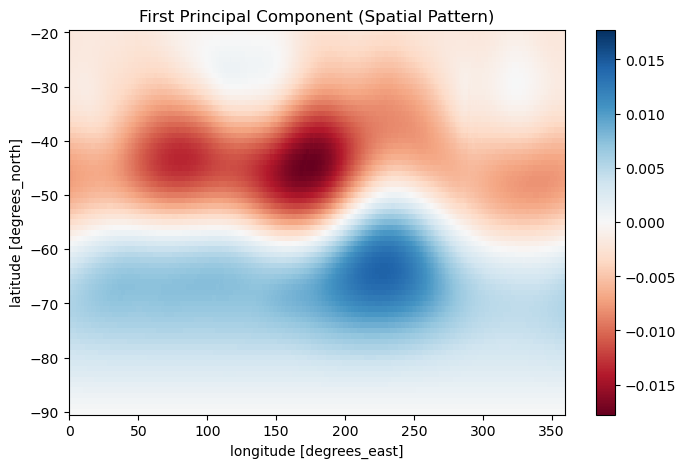

In [77]:
SAM_dict_SON=SAM_process_fast(SON_z500)

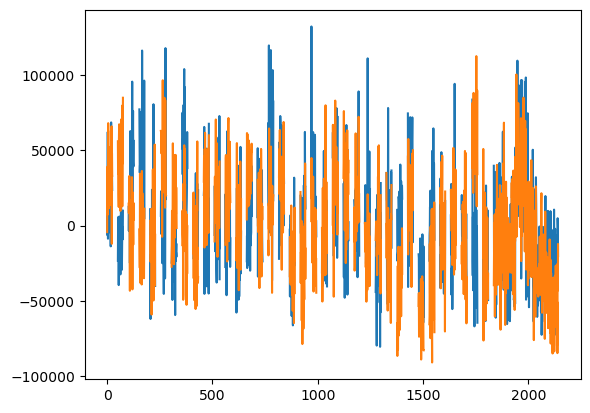

In [93]:
plt.plot(SAM_dict_SON['SAM_sym_coefficient'].values)
plt.plot(SAM_dict_SON['SAM_asym_coefficient'].values)

In [97]:
import pickle

with open("/home/jmindlin/work/Hindcast/sam_results.pkl", "wb") as f:
    pickle.dump(SAM_dict_SON, f)